# Notebook 06: Explainable AI (SHAP and LIME)

In [1]:
%pip install shap lime transformers torch pandas matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import shap
from lime.lime_text import LimeTextExplainer
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## Step 1: Load the trained BERT model

In [3]:
MODEL_PATH = '../models/bert_category'

tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

CATEGORY_NAMES = ['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise']

print('BERT model loaded')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6486.19it/s]


BERT model loaded


## Step 2: Prediction function

In [4]:
def predict_proba(texts):
    """
    Returns probability scores for each class.
    Required format for SHAP and LIME.
    """
    if isinstance(texts, str):
        texts = [texts]

    texts = [str(t) for t in texts]

    encodings = tokenizer(
        texts,
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()

    return probs


# Quick test
test_review = 'The app keeps crashing every time I try to open it'
probs = predict_proba([test_review])
print(f'Review: {test_review}')
print(f'Probabilities: {dict(zip(CATEGORY_NAMES, probs[0].round(3)))}')
print(f'Predicted: {CATEGORY_NAMES[probs[0].argmax()]}')

Review: The app keeps crashing every time I try to open it
Probabilities: {'Bug Report': np.float32(0.764), 'Feature Request': np.float32(0.018), 'UX Feedback': np.float32(0.132), 'Positive Praise': np.float32(0.086)}
Predicted: Bug Report


## Step 3: Select the evaluation sample

In [5]:
test_df = pd.read_csv('../data/processed/test.csv')

N_SAMPLES = 20
frac = N_SAMPLES / len(test_df)

sample_df = (
    test_df.groupby('category_label', group_keys=False)
    .sample(frac=frac, random_state=42)
    .reset_index(drop=True)
)

if len(sample_df) > N_SAMPLES:
    sample_df = sample_df.sample(n=N_SAMPLES, random_state=42).reset_index(drop=True)
else:
    sample_df = sample_df.reset_index(drop=True)

assert 'category_label' in sample_df.columns, "category_label missing: check test.csv columns"

sample_df['predicted_idx'] = sample_df['clean_text'].apply(lambda t: int(predict_proba([t])[0].argmax()))
sample_df['predicted_label'] = sample_df['predicted_idx'].apply(lambda i: CATEGORY_NAMES[i])

print(f'Evaluation sample: {len(sample_df)} reviews')
print(sample_df['category_name'].value_counts())
print(f"\nModel agreement with true label on this sample: "
      f"{(sample_df['category_label'] == sample_df['predicted_idx']).mean()*100:.1f}%")

Evaluation sample: 20 reviews
category_name
Positive Praise    8
Bug Report         6
UX Feedback        4
Feature Request    2
Name: count, dtype: int64

Model agreement with true label on this sample: 75.0%


## Step 4: LIME explanations

In [6]:
explainer = LimeTextExplainer(class_names=CATEGORY_NAMES)


def explain_with_lime(review_text, pred_idx, num_features=10, num_samples=500):
    """
    Generate a LIME explanation for one review, targeting whatever class the
    model actually predicted (pred_idx) instead of LIME's default (label 1).
    """
    exp = explainer.explain_instance(
        review_text,
        predict_proba,
        labels=(pred_idx,),
        num_features=num_features,
        num_samples=num_samples
    )
    return exp


lime_results = []
print('Running LIME on the evaluation sample (this can take a few minutes)...\n')

for _, row in sample_df.iterrows():
    exp = explain_with_lime(row['clean_text'], row['predicted_idx'])
    top_words = exp.as_list(label=row['predicted_idx'])
    lime_results.append(top_words)

# print the first 3 in full just to sanity-check the output
for i in range(3):
    row = sample_df.iloc[i]
    print(f"Review: {row['clean_text'][:150]}")
    print(f"True: {row['category_name']} | Predicted: {row['predicted_label']}")
    print('Top LIME words:')
    for word, score in lime_results[i][:5]:
        direction = 'FOR' if score > 0 else 'AGAINST'
        print(f'  {word}: {score:.4f} ({direction} prediction)')
    print()

Running LIME on the evaluation sample (this can take a few minutes)...

Review: latest update app keeps crashing?????
True: Bug Report | Predicted: Bug Report
Top LIME words:
  crashing: 0.1661 (FOR prediction)
  keeps: -0.0439 (AGAINST prediction)
  app: -0.0280 (AGAINST prediction)
  update: 0.0225 (FOR prediction)
  latest: 0.0105 (FOR prediction)

Review: go for it trust me
True: Positive Praise | Predicted: Positive Praise
Top LIME words:
  for: 0.0876 (FOR prediction)
  trust: 0.0868 (FOR prediction)
  it: 0.0658 (FOR prediction)
  go: -0.0491 (AGAINST prediction)
  me: -0.0196 (AGAINST prediction)

Review: i use it for school
True: Positive Praise | Predicted: Positive Praise
Top LIME words:
  it: 0.1281 (FOR prediction)
  use: 0.0757 (FOR prediction)
  i: -0.0527 (AGAINST prediction)
  school: -0.0339 (AGAINST prediction)
  for: 0.0020 (FOR prediction)



## Step 5: Save a detailed LIME visualisation

LIME explanation saved to ../reports/lime_explanation_sample.html


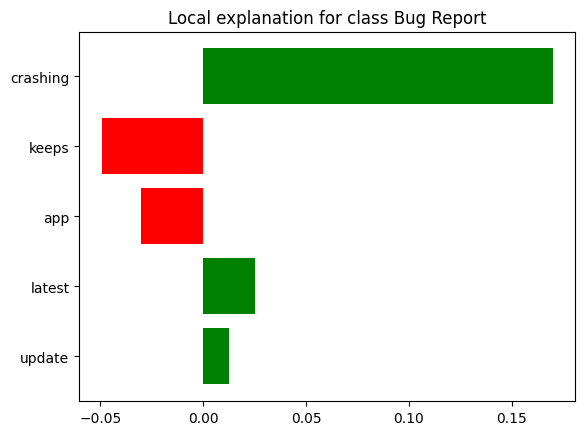

In [7]:
os.makedirs('../reports', exist_ok=True)

sample_row = sample_df.iloc[0]
exp = explain_with_lime(sample_row['clean_text'], sample_row['predicted_idx'])
exp.save_to_file('../reports/lime_explanation_sample.html')
print('LIME explanation saved to ../reports/lime_explanation_sample.html')

fig = exp.as_pyplot_figure(label=sample_row['predicted_idx'])
fig.savefig('../reports/lime_explanation_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: SHAP explanations

In [8]:
masker = shap.maskers.Text(tokenizer)
explainer_shap = shap.Explainer(predict_proba, masker)

print('Computing SHAP values for the evaluation sample (this may take several minutes)...')
shap_values_all = explainer_shap(sample_df['clean_text'].tolist())
print('SHAP values computed for all', len(sample_df), 'reviews')


def merge_subwords(tokens, values):
    """Sum SHAP values across the WordPiece pieces making up each word.

    shap's Text masker emits one token per WordPiece and marks the end of a word
    with trailing whitespace, so 'compliments' arrives as 'compliment' + 's ' and
    'ay' as 'a' + 'y '. Ranking those pieces individually produced explanations
    made of fragments: one review returned {'pal', 'to', 'y'}: which a reader
    cannot interpret, and which is what LIME, already word-level, avoided.

    Summing a word's pieces preserves the additive property of Shapley values, so
    each word's attribution is exact; only the unit of explanation changes, from
    sub-word token to word. The masker's empty boundary tokens correspond to no
    text and are discarded, which shifts the row total by around 1e-4.
    """
    words, word_values = [], []
    buf, buf_value = '', 0.0
    for token, value in zip(tokens, values):
        raw = str(token)
        if not raw:
            continue
        buf += raw.strip()
        buf_value += float(value)
        if raw != raw.rstrip():          # trailing whitespace closes the word
            if buf:
                words.append(buf)
                word_values.append(buf_value)
            buf, buf_value = '', 0.0
    if buf:                              # final word carries no trailing space
        words.append(buf)
        word_values.append(buf_value)
    return words, word_values


def top_shap_words(shap_values_row, pred_idx, top_n=5):
    """Extract the top-n whole words by absolute SHAP contribution for the predicted class."""
    words, values = merge_subwords(
        shap_values_row.data,
        shap_values_row.values[:, pred_idx]
    )
    pairs = sorted(zip(words, values), key=lambda x: abs(x[1]), reverse=True)
    return [(w.strip(), float(v)) for w, v in pairs[:top_n] if w.strip()]


shap_results = [
    top_shap_words(shap_values_all[i], sample_df.iloc[i]['predicted_idx'])
    for i in range(len(sample_df))
]

for i in range(3):
    row = sample_df.iloc[i]
    print(f"\nReview: {row['clean_text'][:150]}")
    print(f"Predicted: {row['predicted_label']}")
    print('Top SHAP words:', shap_results[i][:5])

Computing SHAP values for the evaluation sample (this may take several minutes)...


PartitionExplainer explainer: 21it [00:28,  2.38s/it]                        

SHAP values computed for all 20 reviews

Review: latest update app keeps crashing?????
Predicted: Bug Report
Top SHAP words: [('crashing?????', 0.34901977702975273), ('app', 0.16915109008550644), ('update', 0.14801118429750204), ('keeps', 0.03842668700963259), ('latest', 0.011194335762411356)]

Review: go for it trust me
Predicted: Positive Praise
Top SHAP words: [('trust', 0.2083320152014494), ('for', 0.15388579107820988), ('go', 0.13595552556216717), ('it', 0.09473018907010555), ('me', 0.04605531506240368)]

Review: i use it for school
Predicted: Positive Praise
Top SHAP words: [('use', 0.2089163437485695), ('it', 0.13534313067793846), ('i', 0.10395730845630169), ('for', 0.0892063807696104), ('school', -0.0021101851016283035)]


## Step 7: SHAP visualisation (detailed, single review)

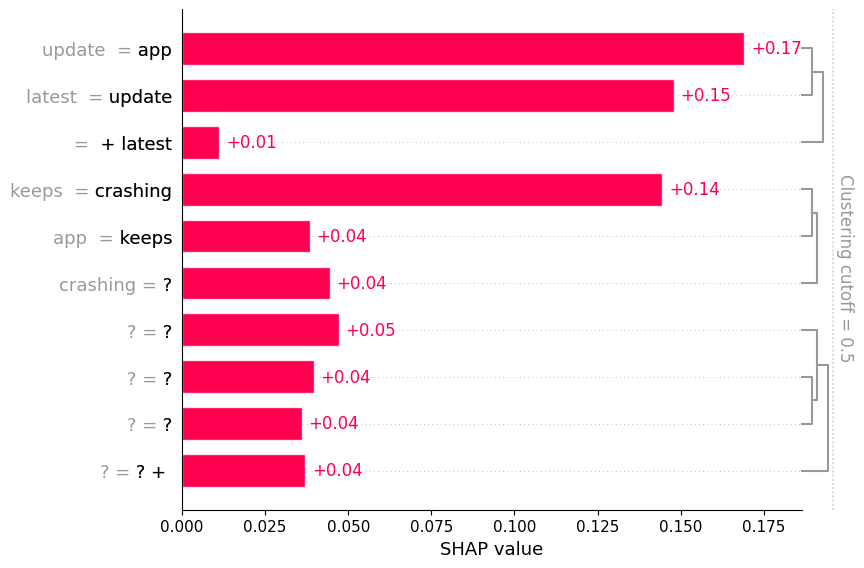

SHAP plots saved to ../reports/


In [9]:
pred_class_idx = int(sample_df.iloc[0]['predicted_idx'])

shap.plots.text(shap_values_all[0, :, pred_class_idx])

# show=False matters here: shap.plots.bar defaults to show=True, which calls plt.show()
# and clears the figure, so savefig would otherwise write a blank canvas.
shap.plots.bar(shap_values_all[0, :, pred_class_idx], show=False)
plt.savefig('../reports/shap_bar_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print('SHAP plots saved to ../reports/')

## Step 8: SHAP vs LIME agreement (RQ2)

In [10]:
import re

def normalise(word):
    return re.sub(r'[^a-z0-9]', '', word.lower().replace('##', ''))


# Overlap is measured like-for-like on each method's five highest-attribution words.
# SHAP already returns five (top_shap_words, top_n=5); LIME is trimmed from ten to its
# top five here so the two sets are the same size. Comparing five words against ten and
# dividing by the smaller set inflates the coefficient, because the longer list has more
# room to contain the shorter one; a top-5-vs-top-5 comparison measures genuine agreement.
agreement_rows = []
for i in range(len(sample_df)):
    row = sample_df.iloc[i]
    shap_words = {normalise(w) for w, _ in shap_results[i]}
    lime_words = {normalise(w) for w, _ in lime_results[i][:5]}
    shap_words.discard('')
    lime_words.discard('')

    overlap = len(shap_words & lime_words)
    denom = min(len(shap_words), len(lime_words)) or 1
    overlap_coef = overlap / denom

    agreement_rows.append({
        'review_id': row.get('review_id', i),
        'true_category': row['category_name'],
        'predicted_category': row['predicted_label'],
        'shap_top_words': ', '.join(sorted(shap_words)),
        'lime_top_words': ', '.join(sorted(lime_words)),
        'shared_words': ', '.join(sorted(shap_words & lime_words)),
        'overlap_coefficient': round(overlap_coef, 3)
    })

agreement_df = pd.DataFrame(agreement_rows)
print('=== SHAP vs LIME Agreement, per review ===\n')
print(agreement_df[['true_category', 'predicted_category', 'shared_words', 'overlap_coefficient']].to_string(index=False))

mean_overlap = agreement_df['overlap_coefficient'].mean()
print(f'\n=== RQ2 answer (this sample) ===')
print(f'Mean SHAP-LIME overlap coefficient across {len(agreement_df)} reviews: {mean_overlap:.3f}')
print('(0 = no agreement, 1 = identical top-5 word sets)')

print('\nAgreement by category:')
print(agreement_df.groupby('true_category')['overlap_coefficient'].mean().round(3))

os.makedirs('../reports', exist_ok=True)
agreement_df.to_csv('../reports/shap_lime_agreement.csv', index=False)
print('\nSaved to ../reports/shap_lime_agreement.csv, cite this table directly in the RQ2 section')

=== SHAP vs LIME Agreement, per review ===

  true_category predicted_category                          shared_words  overlap_coefficient
     Bug Report         Bug Report  app, crashing, keeps, latest, update                  1.0
Positive Praise    Positive Praise                for, go, it, me, trust                  1.0
Positive Praise    Positive Praise               for, i, it, school, use                  1.0
     Bug Report    Feature Request                     an, option, there                  0.6
Feature Request         Bug Report                 delete, don, still, t                  0.8
     Bug Report         Bug Report                          payment, try                  0.4
    UX Feedback        UX Feedback                    access, pay, sadly                  0.6
     Bug Report         Bug Report              5, fix, incredible, star                  0.8
Positive Praise         Bug Report                                   had                  0.2
Positive Praise 

## Step 9: Coherence check (target: 80%)

In [11]:
coherence_template = agreement_df[['review_id', 'true_category', 'predicted_category',
                                     'shap_top_words', 'lime_top_words']].copy()
coherence_template['review_text'] = sample_df['clean_text'].str[:200].values
coherence_template['coherent_Y_N'] = ''
coherence_template['notes'] = ''

coherence_template.to_csv('../reports/coherence_assessment_template.csv', index=False)
print('Template saved to ../reports/coherence_assessment_template.csv')
print('Open this file, fill in coherent_Y_N for each of the 20 rows, then compute:')
print('  pct_coherent = (coherent_Y_N == "Y").mean() * 100')
print('and report that percentage against the >= 80% success criterion in the results chapter.')

Template saved to ../reports/coherence_assessment_template.csv
Open this file, fill in coherent_Y_N for each of the 20 rows, then compute:
  pct_coherent = (coherent_Y_N == "Y").mean() * 100
and report that percentage against the >= 80% success criterion in the results chapter.


## Step 10: Score the completed assessment

The template above was filled in by hand, judging each explanation against the
*predicted* class rather than the gold label, since the question is whether the
explanation justifies what the model actually did.

In [14]:
# Read back the completed assessment and score it against the success criterion.
# This is the cell that produces the headline coherence percentage.
coherence = pd.read_csv('../reports/coherence_assessment_completed.csv')
n_coherent = (coherence['coherent_Y_N'] == 'Y').sum()
pct = n_coherent / len(coherence) * 100

print(f'Coherent explanations: {n_coherent}/{len(coherence)} = {pct:.0f}%')
print(f'Success criterion:     >= 80%')
print(f'Outcome:               {"MET" if pct >= 80 else "MISSED"} by {abs(pct - 80):.0f} percentage points')
print()
print('By predicted category:')
by_cat = coherence.groupby('predicted_category')['coherent_Y_N'].agg(
    n='size', coherent=lambda s: (s == 'Y').sum())
by_cat['pct'] = (by_cat['coherent'] / by_cat['n'] * 100).round(0)
print(by_cat.to_string())
print()
print('The 6 incoherent explanations:')
for _, r in coherence[coherence['coherent_Y_N'] == 'N'].iterrows():
    print(f"  predicted {r['predicted_category']:16s} | {str(r['notes'])[:88]}")

Coherent explanations: 14/20 = 70%
Success criterion:     >= 80%
Outcome:               MISSED by 10 percentage points

By predicted category:
                    n  coherent    pct
predicted_category                    
Bug Report          9         6   67.0
Feature Request     2         2  100.0
Positive Praise     7         4   57.0
UX Feedback         2         2  100.0

The 6 incoherent explanations:
  predicted Positive Praise  | Top words are all function words (for, go, it, me, trust); none carries positive sentime
  predicted Positive Praise  | Top words (for, i, it, school, use) are purely descriptive stopwords; nothing signals pr
  predicted Bug Report       | Although LIME surfaces 'bugs' and both lists include 'fix', the explanation is dominated
  predicted Bug Report       | Top words (had, not, thought, tin / awake, ended, review, story) are generic and give no
  predicted Bug Report       | Top words (acount, deleted, pay, realized) describe a pricing/paywall grievance,